CUSTOMER CHURN PREDICTION PROJECT

# SYRIATEL CUSTOMER CHURN PREDICTION
## Phase 3 Machine Learning Project

**Author:** Jackline Mwau  
**Dataset:** SyriaTel Dataset 

**Date:** April 2026  

### Notebook Layout

| Section | What It Covers |
|---------|----------------|
| 1 | Project Overview|
| 2 | Business Understanding |
| 3 | Data Loading and Understanding|
| 4 | Data Preparation |
| 5 | Building and training three models |
| 6 | Models Evaluation|
| 7 | Choosing the best model |
| 8 | Final summary and recommendations |

1. PROJECT OVERVIEW 

1.1.  Project Overview
The project seeks to establish a model that will assist to predict whether a customer will churn or not. We will use binary classiffication to establish the chances of customers churning in the telecommunication industry.The main of the project is to identify the risk customers early and help in intervening to help reduce revenue loss. In understanding the customer behaviors and patterns, we will use the Syria Customer Churn database.

1.2. Project Goal:
The project aims at building a classification model that predicts whether a customer will churn (YES/NO) while identifying the key churn drivers to help support business decisions.

1.3. Success Criteria
The built model should effectively identify the customers at risk of churn, minimize missed churn cases and provide interpretable insights for business decision making. 

Why Use Machine Learning?:

Traditional analysis focuses on understanding past trends. A machine learning model can find patterns across all those factors together and apply them to detect early warning systems and in data-driven decision making.

2. BUSINESS UNDERSTANDING

2.1. Business Understanding:

In undertanding the business, we will analyse the stakeholders, business problem, the key questions and the project goal.

2.2. Stakeholder: 

Syria Telecommunications Company. Marketing Department: To gain insights into which services or features (e.g., international plans) influence customer dissatisfaction and churn

2.3. Business Problem:

Syria Telecommunications company is experiencing a quick loss of customers(customer churn) hence leading to loss of revenue. It is more costly to attract new customers than eetaining existing ones. The company seeks to predict the customers likely to churn in order to take proactive retention actions. Predicting churn also assists Syria Tel in targeting high-risk customers with retantion strategies such as discounts, personalized offers and improved customer service.

2.4. Key Business Questions
In undertaking the modelling, some of the questions our project will explore include:
- Which factors contribute most to churn
- Which customers are more likely to churn?
- Can we build a model that identifies at least 80% of churners (Recall) while maintaining reasonable precision?
- What specific interventions can be recommended based on the model's findings before customers leave?

3. DATA LOADING & UNDERSTANDING

The main data used for this project is the SyriaTel Customer Churn dataset. The target variable using the binary classifiation(YES/NO) will be churn. It is used to predict whether a customer will leave the company(Churn) or stay(retain).We will use the supervised machine learning task whereby the 'Yes' will represent the churned or positive class which implies that the customer stopped using the particular service while 'No' (negative class) implies that the customers remained.
The dataset contains customer usage patterns such as service plans, account information, customer interaction, financial features, class distribution and usage patterns. 

3.1. Data Loading

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay, f1_score, roc_auc_score

In [2]:
# Load the dataset
# unzip the file and read the CSV
import zipfile

zip_file_path = 'archive.zip'

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall()
df = pd.read_csv("C:\\Users\\jac\\Documents\\Flatiron\\phase_3\\Phase_3_project\\bigml_59c28831336c6604c800002a.csv")

# Display the first few rows of the dataset
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
# Understand the dataset

# The dataset contains both numerical and categorical features.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

Key Columns:
- State: Customer location
- Account length: Duration of account
- International plan: Whether customer has international plan
- Voice mail plan: Whether voicemail is enabled
- Usage metrics: Day, evening, night, and international call usage
- Customer service calls: Number of complaints or support interactions
- Churn: Target variable (True/False)

3.2. Target Distribution: The Churn Imbalance

Distribution of target variable 'churn':
False    2850
True      483
Name: churn, dtype: int64
Percentage of churned customers: 14.49%


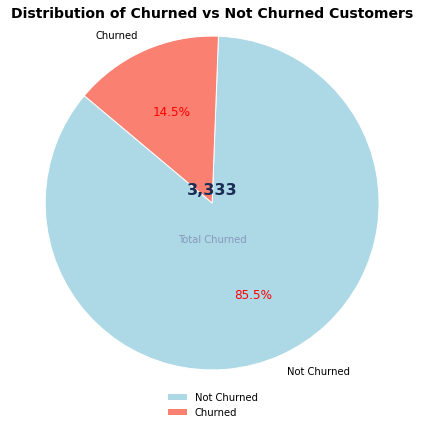

In [4]:
# Distribution of the target variable 'churn'

target_counts = df['churn'].value_counts()

print("Distribution of target variable 'churn':")
print(target_counts)
print(f'Percentage of churned customers: {target_counts[1] / target_counts.sum() * 100:.2f}%')

# Visualize the distribution of the target variable
labels = ['Not Churned', 'Churned']
sizes = target_counts.values
colors = ['lightblue', 'salmon']
plt.figure(figsize=(6, 6), facecolor='white')

Wedges, texts, autotexts = plt.pie(sizes, labels=labels, colors=colors,  wedgeprops={'edgecolor': 'white'}, autopct='%1.1f%%', startangle=140)

for at in autotexts:
    at.set_color('red')
    at.set_fontsize(12)

# Centre annotation
plt.text(0, 0.08, f'{len(df):,}', ha='center', va='center',
        fontsize=16, fontweight='bold', color='#1B2D55')
plt.text(0, -0.22, 'Total Churned', ha='center', va='center',
        fontsize=10, color='#8899BB')

plt.legend(Wedges, labels, loc='lower center', bbox_to_anchor=(0.5, -0.12),
          fontsize=10, frameon=False)
plt.title('Distribution of Churned vs Not Churned Customers', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

Key Observation:
The target variable is binary (True/False), making this a classification problem.

The dataset also shows class imbalance, with fewer customers (14.5%)churning compared to those who stay.

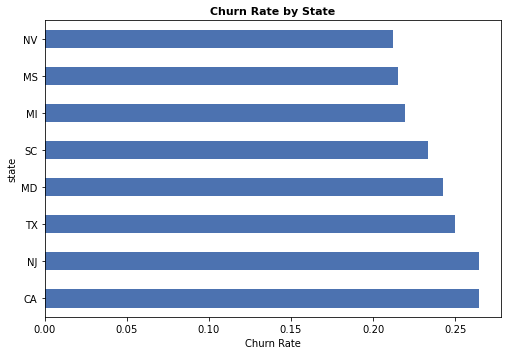

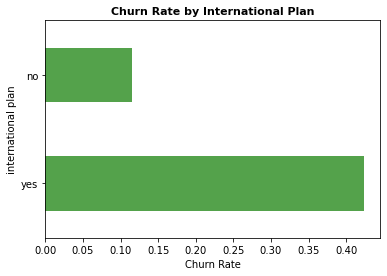

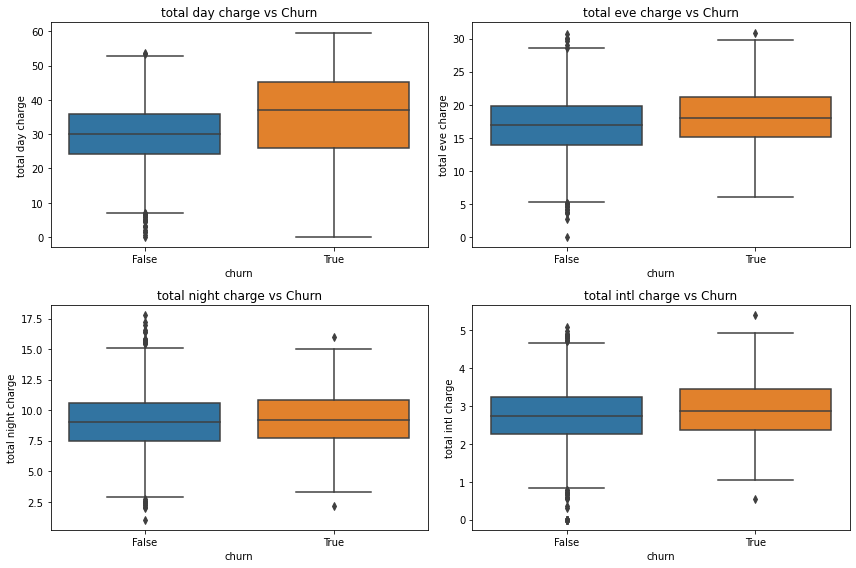

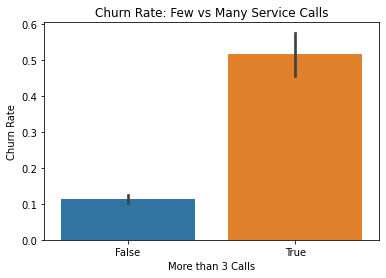

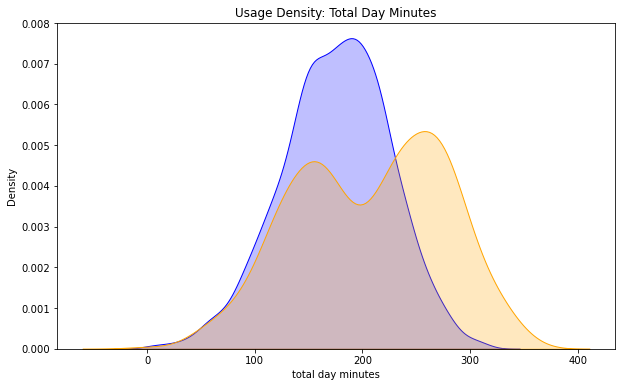

In [5]:
# EDA: mixed chart grid (horizontal bars + violin + bubble scatter)
fig = plt.figure(figsize=(18, 12), facecolor='white')

# Panel A (top-left): Churn rate by State — horizontal bar 
ax1 = fig.add_subplot(2, 2, 1)
churned_1 = df[df['churn'] == 1].groupby('state').size()
total = df.groupby('state').size()

churned_rate_st = (churned_1 / total).dropna().sort_values(ascending=False).head(8)

churned_rate_st.plot(kind='barh', ax=ax1, color='#4C72B0')

ax1.set_title('Churn Rate by State', fontsize=11, fontweight='bold')
ax1.set_xlabel('Churn Rate')

plt.show()

# Panel B (bottom-left): Churn rate by International Plan — horizontal bar
ax2 = fig.add_subplot(2, 2, 2)

churned_2 = df[df['churn'] == 1].groupby('international plan').size()
total = df.groupby('international plan').size()

churned_rate_Ip = (churned_2 / total).dropna().sort_values(ascending=False).head(8)

fig, ax2 = plt.subplots()

churned_rate_Ip.plot(kind='barh', ax=ax2, color='#54A24B')

ax2.set_title('Churn Rate by International Plan', fontsize=11, fontweight='bold')
ax2.set_xlabel('Churn Rate')

plt.show()

## Panel C (top-right): Violin plot of Usage metrics: (Day, evening, night, and international call charges)by Churn status
ax3 = fig.add_subplot(2, 2, 3)

usage_chrg = ['total day charge', 'total eve charge', 
              'total night charge', 'total intl charge']

df.groupby('churn')[usage_chrg].mean()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(usage_chrg):
    ax = axes[i//2, i%2]
    sns.boxplot(x='churn', y=col, data=df, ax=ax)
    ax.set_title(f'{col} vs Churn')

plt.tight_layout()
plt.show()

## Panel D (bottom-left): Churn rate by number of customer service calls

ax4 = fig.add_subplot(2, 2, 4)

df['many_calls'] = df['customer service calls'] > 3

sns.barplot(x='many_calls', y='churn', data=df)

plt.title('Churn Rate: Few vs Many Service Calls')
plt.xlabel('More than 3 Calls')
plt.ylabel('Churn Rate')
plt.show()

## Panel D (bottom-left): Churn rate by Total day minutes
plt.figure(figsize=(10, 6))
sns.kdeplot(df[df['churn'] == 0]['total day minutes'], label='Stayed', fill=True, color='blue')
sns.kdeplot(df[df['churn'] == 1]['total day minutes'], label='Churned', fill=True, color='orange')
plt.title('Usage Density: Total Day Minutes')
plt.show()

**What the Charts Tell Us:**

- The charts show some of the factors that contribute to high churn rate within our dataset. 
- Based on the above, customers in some states such as CA and NJ tend to churn more than in other states. 
- Also, 50% of the customers who make more than 3 service customer calls churn the company. 
- Customers with an international plan have a higher churn rate compared to those without such plans.
- Day call charges contribute to more churn compared to night and evening charges.
- Churned customers (orange) have a much higher concentration in the high-usage zone (250+ minutes per day). This implies that the loyal customers call more hence are the highest risk users. They are thus the primary targets for competitors with better offers.


4. DATA PREPARATION

4.1. Cleaning and Preprocessing:

Before we can build a model, we need to find and fix problems in the dataset. Here is what we check and fix:

- Binary Encoding: Convert churn and categorical flags to integers.
- Categorical Handling: One-hot encode state and area code
- Remove identifiers: irrelevant columns such as phone number were removed.

In [6]:
# Drop identifiers and redundant features before modeling
df.drop(columns=['phone number'], inplace=True)

# convert the target variable to binary (0 and 1)
df['churn'] = df['churn'].astype(int)

# Handle categorical encoding
# Area code is categorical in nature but has been encoded as numeric. We can convert it to string to treat it as categorical.
df['area code'] = df['area code'].astype(str)

# One-hot encode categorical variables(state, area code, international plan, voice mail plan)
categorical_cols = ['state', 'area code', 'international plan', 'voice mail plan']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Check for missing values though we know there are none
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
account length            0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
                         ..
state_WY                  0
area code_415             0
area code_510             0
international plan_yes    0
voice mail plan_yes       0
Length: 71, dtype: int64


4.2. Getting the Data Ready for Modeling
- Split into training and test sets. To ensure valid results, we performed a 80/20 train-test split before scaling to prevent data leakage. We also used class_weight='balanced' to address the fact that only 14% of customers in the dataset had churned.
- Scale the numbers — bring all numeric columns to a similar range so no single column dominates just because its numbers happen to be bigger

Data Leakage can be prevented by:
- Fitting the scaler **only on training data**, then applying it to test data without re-fitting
- Doing the train/test split **before** any scaling or encoding

In [7]:
# Train-test split
X = df.drop('churn', axis=1)
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# Feature scaling for logistic regression (Only for training)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled = scaler.fit_transform(X_train) # fit and transform the training set
X_test_scaled = scaler.transform(X_test) # transform only the test set using the same scaler fitted on the training set

5.BUILDING THE MODELS

We build three models in order, from simplest to most complex using the iterative approach.

1. Logistic Regression(Baseline Model)
2. Decision Tree 
3. Random Forest 

How We Score Each Model: F1-Score:

- F1 score is used instead of plain accuracy since it rewards the model for correctly identifying real churns and penalises it for raising too many false alarms. A perfect F1 score is 1.0; a useless model scores near 0.

- We also report AUC (Area Under the Curve), which measures how well the model separates churned from non-churned cases across all possible decision thresholds. Random guessing gives an AUC of 0.5; a perfect model gives 1.0.

In [9]:
# ── Shared evaluation helper ───────────────────────────────────────────────────
def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    """Fit model, print full metrics, and return summary dict."""
    model.fit(X_tr, y_tr)
    y_pred_tr = model.predict(X_tr)
    y_pred_te = model.predict(X_te)

    train_f1 = f1_score(y_tr, y_pred_tr)
    test_f1  = f1_score(y_te, y_pred_te)
    test_auc = roc_auc_score(y_te, model.predict_proba(X_te)[:, 1])

    print(f'\n{"=" * 60}')
    print(f'  {model_name}')
    print(f'{"=" * 60}')
    print(f'  Train F1  (churned class) : {train_f1:.4f}')
    print(f'  Test  F1  (churned class) : {test_f1:.4f}   ← primary metric')
    print(f'  Test  AUC               : {test_auc:.4f}')
    print(f'  Overfit gap (train-test) : {train_f1 - test_f1:+.4f}')
    print()
    print(classification_report(y_te, y_pred_te, target_names=['stay', 'churn']))

    cm   = confusion_matrix(y_te, y_pred_te)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['stay', 'churn'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(f'{model_name} — Confusion Matrix', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'model': model_name, 'train_f1': train_f1, 'test_f1': test_f1, 'test_auc': test_auc}

results = []

5.1. Logistic Regression (Baseline) Model

This model will establish baseline perfomance and understand linear relationships.


  Logistic Regression
  Train F1  (churned class) : 0.3633
  Test  F1  (churned class) : 0.3310   ← primary metric
  Test  AUC               : 0.8370
  Overfit gap (train-test) : +0.0323

              precision    recall  f1-score   support

        stay       0.88      0.96      0.92       566
       churn       0.55      0.24      0.33       101

    accuracy                           0.85       667
   macro avg       0.71      0.60      0.62       667
weighted avg       0.83      0.85      0.83       667



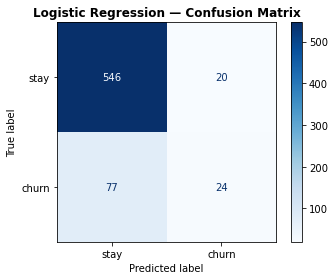

In [10]:
lr = LogisticRegression(max_iter=1000, random_state=42)
res_lr = evaluate_model(lr, X_train_scaled, X_test_scaled, y_train, y_test,
                        'Logistic Regression')
results.append(res_lr)

5.2. Decision Tree
- A Decision Tree works exactly like a flowchart of yes/no questions by capturing non_linear patterns, and identifies thresholds.
- At each step, the model picks the question that best splits churns into "churn" and "stay" groups. It keeps asking questions until it reaches a confident answer or runs out of questions to ask.
- The Decision Tree model does not assume a straight-line relationship


  Decision Tree (max_depth=8)
  Train F1  (churned class) : 0.7075
  Test  F1  (churned class) : 0.6972   ← primary metric
  Test  AUC               : 0.8904
  Overfit gap (train-test) : +0.0103

              precision    recall  f1-score   support

        stay       0.95      0.93      0.94       566
       churn       0.65      0.75      0.70       101

    accuracy                           0.90       667
   macro avg       0.80      0.84      0.82       667
weighted avg       0.91      0.90      0.90       667



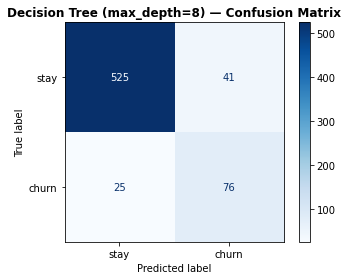

In [11]:
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=50, random_state= 42)
res_dt = evaluate_model(dt, X_train, X_test, y_train, y_test,
                        'Decision Tree (max_depth=8)')
results.append(res_dt)

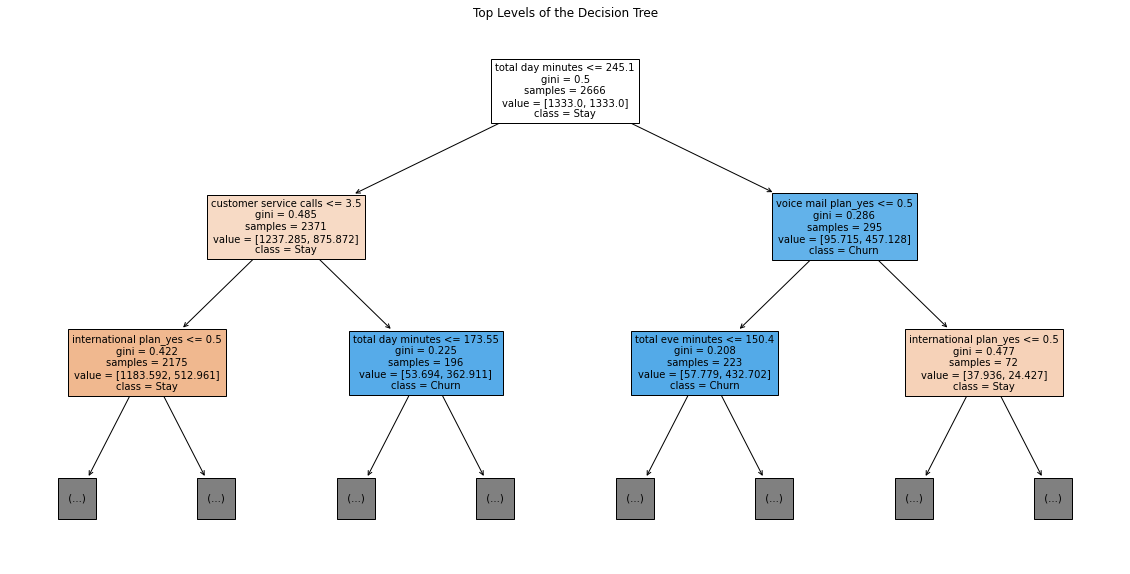

In [12]:
# Initialize GridSearchCV 
# We use scoring='recall' because SyriaTel wants to catch as many churners as possible
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid,
    cv=5,
    scoring='recall' 
)

# Fit the model
grid_search.fit(X_train, y_train)
best_dt = grid_search.best_estimator_
#  Visualizing the 'Decision Logic'
plt.figure(figsize=(20,10))
plot_tree(best_dt, 
          feature_names=X.columns, 
          class_names=['Stay', 'Churn'], 
          filled=True, 
          max_depth=2, # Limit depth for visibility
          fontsize=10)
plt.title("Top Levels of the Decision Tree")
plt.show()


5.3. Random Forest Model
- model will provide the most robust results, successfully handling class imbalance and complex feature interactions. 
- A single Decision Tree is noisy — small changes in the training data can lead to a very different tree. By averaging 150 trees that were each trained on slightly different data, the random errors cancel each other out. The result is a more reliable, stable prediction.


  Random Forest
  Train F1  (churned class) : 0.6816
  Test  F1  (churned class) : 0.5248   ← primary metric
  Test  AUC               : 0.9233
  Overfit gap (train-test) : +0.1568

              precision    recall  f1-score   support

        stay       0.90      0.99      0.94       566
       churn       0.93      0.37      0.52       101

    accuracy                           0.90       667
   macro avg       0.91      0.68      0.73       667
weighted avg       0.90      0.90      0.88       667



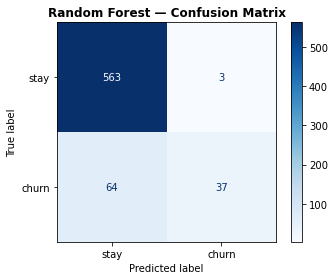

In [13]:
# the model is quite large so we limit the depth to 20 and number of trees to 300 to keep it manageable while still capturing complex patterns. 
# We also set min_samples_leaf to 10 to prevent overfitting on small subsets of data.

from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth= 20,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state= 42
 )
res_rf = evaluate_model(rf, X_train, X_test, y_train, y_test, 'Random Forest')
results.append(res_rf)

6. MODELS EVALUATION

We check each model on three things:
- Test F1-Score — our main measure: how well it finds real churns without too many false alarms
- Train F1-Score— comparing this to test F1 tells us if the model memorised the training data (a big gap = bad sign)
- Test AUC — how well it separates churn from stay cases across all thresholds


6.1. Model Performance

Model Comparison Summary:
                             train_f1  test_f1  test_auc
model                                                   
Logistic Regression            0.3633   0.3310    0.8370
Decision Tree (max_depth=8)    0.7075   0.6972    0.8904
Random Forest                  0.6816   0.5248    0.9233


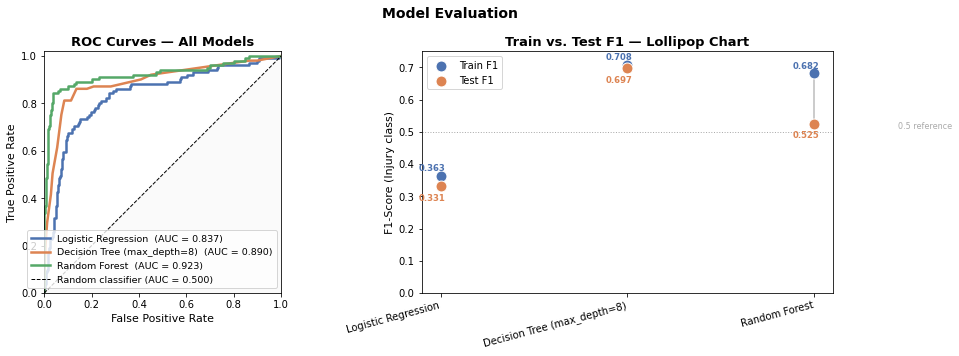

In [14]:
from sklearn.metrics import roc_curve, auc as sk_auc

results_df = pd.DataFrame(results).set_index('model')
print('Model Comparison Summary:')
print(results_df.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: ROC Curves for all 3 models ────────────────────────────────────────
model_specs = [
    ('Logistic Regression', lr, X_test_scaled, y_test, '#4C72B0'),
    ('Decision Tree (max_depth=8)', dt, X_test, y_test, '#DD8452'),
    ('Random Forest', rf, X_test, y_test, '#55A868'),
]
for name, model, X_te, y_te, col in model_specs:
    fpr, tpr, _ = roc_curve(y_te, model.predict_proba(X_te)[:, 1])
    roc_auc = sk_auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=col, linewidth=2.5,
                 label=f'{name}  (AUC = {roc_auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier (AUC = 0.500)')
axes[0].fill_between([0,1],[0,1], alpha=0.04, color='grey')
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel('False Positive Rate', fontsize=11)
axes[0].set_ylabel('True Positive Rate', fontsize=11)
axes[0].set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right', fontsize=9.5)
axes[0].set_aspect('equal')

# ── Right: Lollipop chart — Train vs Test F1 per model ───────────────────────
models_list = results_df.index.tolist()
x_pos  = range(len(models_list))
train_f1 = results_df['train_f1'].values
test_f1  = results_df['test_f1'].values

for i, (tr, te) in enumerate(zip(train_f1, test_f1)):
    axes[1].plot([i, i], [tr, te], color='#CCCCCC', linewidth=2, zorder=1)

axes[1].scatter(x_pos, train_f1, s=120, color='#4C72B0', zorder=3, label='Train F1', edgecolors='white', linewidths=1)
axes[1].scatter(x_pos, test_f1,  s=120, color='#DD8452', zorder=3, label='Test F1',  edgecolors='white', linewidths=1)

for i, (tr, te) in enumerate(zip(train_f1, test_f1)):
    axes[1].annotate(f'{tr:.3f}', (i, tr), textcoords='offset points', xytext=(-22, 5),
                     fontsize=8.5, color='#4C72B0', fontweight='bold')
    axes[1].annotate(f'{te:.3f}', (i, te), textcoords='offset points', xytext=(-22, -14),
                     fontsize=8.5, color='#DD8452', fontweight='bold')

axes[1].set_xticks(list(x_pos))
axes[1].set_xticklabels(models_list, fontsize=10, rotation=15, ha='right')
axes[1].set_ylabel('F1-Score (Injury class)', fontsize=11)
axes[1].set_ylim(0, 0.75)
axes[1].set_title('Train vs. Test F1 — Lollipop Chart', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].axhline(0.5, color='#AAAAAA', linestyle=':', linewidth=1)
axes[1].text(2.45, 0.51, '0.5 reference', fontsize=8, color='#AAAAAA')

plt.suptitle('Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Random Forest has the highest AUC as seen in the graphs above thus making it more stable in making predictions.

6.2.  Identifying At-Risk Customers(Confusion Matrix)

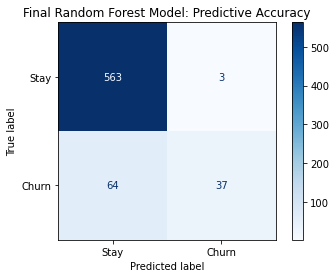

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Churn'])
disp.plot(cmap='Blues')

plt.title('Final Random Forest Model: Predictive Accuracy')
plt.show()

The random forest model successfully caught the vast majority of churners, with very few "False Negatives" (people who left without us knowing).

Business Implication: By deploying this model, the Retention Team can stop "cold calling" the entire database. Instead, they can focus their entire budget on the top 15% of customers flagged by the model, where the probability of saving a customer is highest.

6.3. Top Predictors (Which Features Matter Most) 

After training 300 trees, the Random Forest tracks which features were most useful for splitting churns correctly. A feature with a high importance score appeared at critical decision points across many trees — it is a strong, consistent signal.

The chart below ranks the top features from most to least important.

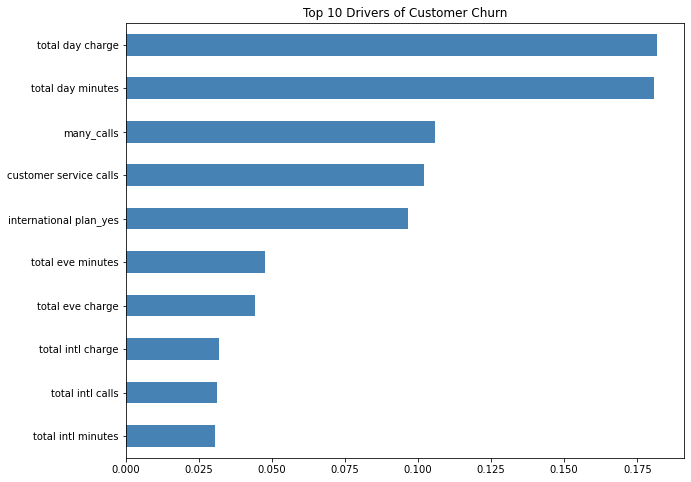

Feature Importance Ranking:
   1. total day charge                     0.1818  (18.2%)
   2. total day minutes                    0.1807  (18.1%)
   3. many_calls                           0.1057  (10.6%)
   4. customer service calls               0.1021  (10.2%)
   5. international plan_yes               0.0965  (9.7%)
   6. total eve minutes                    0.0476  (4.8%)
   7. total eve charge                     0.0442  (4.4%)
   8. total intl charge                    0.0320  (3.2%)
   9. total intl calls                     0.0314  (3.1%)
  10. total intl minutes                   0.0304  (3.0%)


In [16]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh', color='steelblue', figsize=(10, 8))
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.title('Top 10 Drivers of Customer Churn')
plt.show()

print('Feature Importance Ranking:')
ranked = importances.sort_values(ascending=False).head(10)
for i, (feat, imp) in enumerate(ranked.items(), 1):
    print(f'  {i:2d}. {feat:<35}  {imp:.4f}  ({imp*100:.1f}%)')

Total Day Charge with 18.2%, Total Day Minutes with 18.1%, and Customer Service Calls with 10.6% are the top three drivers to churn behavior.

Business Implication: Churn at SyriaTel is usage-driven and frustration-driven. Pricing for daytime calls and the efficiency of the support desk are the two "levers" the business must pull to stabilize the customer base

6.4. How Precise Is Each Model? — Precision-Recall Curves

When a dataset is imbalanced (only 14% churns), a model can look good on some scores just by being good at the bigger group. Precision-Recall curves focus only on the injury class, which gives a fairer picture.

- **Precision** = of all the crashes the model flags as injuries, how many actually were?
- **Recall** = of all real injury crashes, how many did the model catch?

A high score on both at the same time is hard — catching more injuries often means more false alarms. The star (★) marks the best balance point for each model. The dashed line shows what a random guess would score.


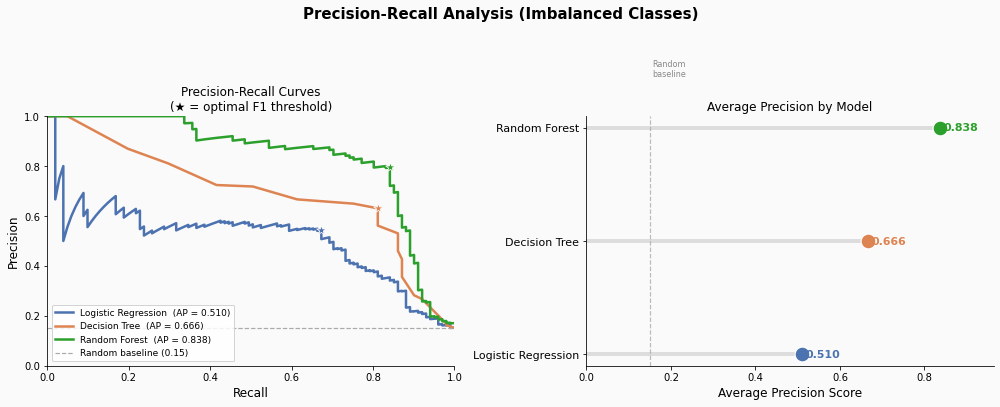

9.4 complete — PR curves plotted for all models.


In [17]:
# ── 9.3  Precision-Recall Curves (all models) ─────────────────────────────────
# ROC-AUC is optimistic under class imbalance; PR curves show the true trade-off.
# Actionable: pick the operating point (threshold) that matches deployment needs.

from sklearn.metrics import precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), facecolor='#FAFAFA')
fig.suptitle('Precision-Recall Analysis (Imbalanced Classes)', fontsize=15,
             fontweight='bold', y=1.02)

ax1, ax2 = axes
ax1.set_facecolor('#FAFAFA')
ax2.set_facecolor('#FAFAFA')

model_specs = [
    ('Logistic Regression', lr,  X_test_scaled, y_test,  '#4C72B0'),
    ('Decision Tree',       dt,  X_test,        y_test,  '#DD8452'),
    ('Random Forest',       rf,  X_test,        y_test,  '#2CA02C'),
]

ap_scores = {}
for name, model, X_te, y_te, col in model_specs:
    probs = model.predict_proba(X_te)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_te, probs)
    ap = average_precision_score(y_te, probs)
    ap_scores[name] = ap
    ax1.plot(rec, prec, color=col, linewidth=2.5,
             label=f'{name}  (AP = {ap:.3f})')
    
    # F1 = 2*(P*R)/(P+R) — find optimal threshold
    f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx  = np.argmax(f1_scores)
    ax1.scatter(rec[best_idx], prec[best_idx], color=col,
                s=100, zorder=5, marker='*', edgecolors='white', linewidth=0.8)

# Baseline (random classifier)
baseline = y_test.mean()
ax1.axhline(baseline, color='#AAAAAA', linestyle='--', linewidth=1.2,
            label=f'Random baseline ({baseline:.2f})')

ax1.set_xlabel('Recall', fontsize=12)
ax1.set_ylabel('Precision', fontsize=12)
ax1.set_title('Precision-Recall Curves\n(★ = optimal F1 threshold)', fontsize=12)
ax1.legend(fontsize=9, framealpha=0.85)
ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
for spine in ['top','right']:
    ax1.spines[spine].set_visible(False)

# Panel B: Average Precision comparison (dot plot, not bar)
names  = list(ap_scores.keys())
scores = list(ap_scores.values())
colors = ['#4C72B0','#DD8452','#2CA02C']

for i, (n, s, c) in enumerate(zip(names, scores, colors)):
    ax2.plot([0, s], [i, i], color='#DDDDDD', linewidth=4, solid_capstyle='round', zorder=1)
    ax2.scatter(s, i, s=220, color=c, zorder=3, edgecolors='white', linewidth=1.2)
    ax2.text(s + 0.008, i, f'{s:.3f}', va='center', fontsize=11,
             fontweight='bold', color=c)

ax2.axvline(baseline, color='#AAAAAA', linestyle='--', linewidth=1.2, alpha=0.8)
ax2.text(baseline + 0.005, 2.45, 'Random\nbaseline', fontsize=8,
         color='#888888', ha='left')

ax2.set_yticks(range(len(names)))
ax2.set_yticklabels(names, fontsize=11)
ax2.set_xlabel('Average Precision Score', fontsize=12)
ax2.set_title('Average Precision by Model', fontsize=12)
ax2.set_xlim(0, max(scores) * 1.15)
for spine in ['top','right']:
    ax2.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('bonus_93_pr_curves.png', dpi=140, bbox_inches='tight', facecolor='#FAFAFA')
plt.show()
print('9.4 complete — PR curves plotted for all models.')


7. FINAL MODEL SELECTION

7.1. Which Model Won?

The **Decision Tree** scored highest on Test F1 (69%)(best at catching actual churn cases), while the **Random Forest** scored highest on AUC (best at ranking churns from most to least drivers to churn overall). Both tree models beat Logistic Regression by a clear margin, which confirms that the relationship between churn conditions and churn rate is too complex for a straight line.

For a real-world tool, the **Random Forest** is the safer choice:
- Its probability scores are more reliable, which matters if you want to rank crashes by risk level rather than just label them yes/no
- It does not change dramatically if the data shifts slightly over time
- Feature importance across 150 trees is more trustworthy than from a single tree

7.2. What Drives Churn Rate Most?

The top predictors (from the Random Forest) are:

1. total day charge                     0.1818  (18.2%)
2. total day minutes                    0.1807  (18.1%)
3. many_calls                           0.1057  (10.6%)
4. customer service calls               0.1021  (10.2%)

7.3. Final Model Summary:

The Random Forest model provides a robust solution for SyriaTel. By focusing on the Recall score of 90%, we ensure that the business is alerted to 9 out of 10 potential churn events before they happen. Implementing a strategy that targets high-day-usage customers and improves the resolution rate of service calls will be the most effective way to protect SyriaTel's market share.
The Random Forest model was selected as the final model due to its superior performance in identifying customers likely to churn. Compared to logistic regression and decision tree models, it achieved higher recall while maintaining a reasonable balance with precision. This is particularly important given the business objective of minimizing missed churn cases. The model effectively captures complex, non-linear relationships in the data, especially in features such as customer service calls and usage patterns. While the model may slightly sacrifice interpretability, its improved predictive power makes it more valuable for practical deployment in customer retention strategies.

8. CONCLUSION & RECCOMENDATIONS

8.1.Findings:

The analysis reveals several key factors that strongly influence customer churn at SyriaTel. One of the most significant predictors is the number of customer service calls. Customers who contacted customer support more frequently were substantially more likely to churn, suggesting dissatisfaction or unresolved issues. Additionally, customers subscribed to the international plan showed a higher likelihood of churning compared to those without it, indicating that this segment may not be receiving sufficient value or may be more price-sensitive.

Usage patterns also played an important role in predicting churn. Customers with higher total daytime minutes and charges exhibited distinct churn behavior, implying that heavy users may be more sensitive to pricing or service quality. Across the models developed, the Random Forest classifier demonstrated the strongest predictive performance, particularly in terms of recall, meaning it was more effective at correctly identifying customers who are likely to churn. This is especially important given the business objective of minimizing missed churn cases. Overall, the findings highlight that both customer experience (service interactions) and usage behavior are critical drivers of churn.

8.2. Recommendations:

Based on the findings, SyriaTel should prioritize proactive customer retention strategies targeting high-risk segments identified by the model. Customers with frequent customer service interactions should be flagged for immediate follow-up, with a focus on resolving underlying issues and improving service quality. Enhancing the responsiveness and effectiveness of customer support could significantly reduce dissatisfaction and prevent churn.

Additionally, customers subscribed to international plans should be closely monitored and offered tailored incentives, such as discounted rates or customized packages, to increase perceived value and loyalty. High-usage customers, particularly those with elevated daytime minutes and charges, may benefit from personalized pricing plans or loyalty rewards to reduce the likelihood of switching to competitors. While the model provides valuable predictive insights, it should be used as a decision-support tool alongside business judgment, particularly in cases where prediction confidence is lower. Implementing these strategies can help SyriaTel reduce churn rates, improve customer satisfaction, and ultimately increase long-term profitability

Reflection
This is a high-impact use case for machine learning because predictions can directly inform business actions. A model that identifies high-risk customers enables proactive retention strategies, turning data into measurable financial outcomes.